# MMP GRN Biology Case Study

Single-cell multiomics of bone marrow (MMP/GSE311602). Two measurement modalities: multiome (10x RNA+ATAC) and dogma (DOGMA-seq). Analysis: top TFs by out-degree, GWAS gene in-degree, TF coverage vs PBMC markers and MMP disease TFs, motif DB coverage.

## 1. General Imports and Parameter Definitions

In [27]:
%reload_ext autoreload
%autoreload 2
import os, sys, pickle
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
plt.rcParams['font.family'] = 'Arial' # Arial or 'Liberation Sans'
default_font = matplotlib.rcParams['font.family']
print(default_font)

['Arial']


In [28]:
# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_DIR  = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/results/MMP'
OUT_DIR      = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP'
os.makedirs(OUT_DIR, exist_ok=True)

# geneRNIB imports
sys.path.insert(0, '/home/jnourisa/projs/ongoing')
sys.path.insert(0, '/home/jnourisa/projs/ongoing/geneRNIB')
from src.helper import surrogate_names, palette_methods, colors_blind
from src.MMP.constants import IMMUNE_CORE_TFS, MMP_LITERATURE_TFS, get_mmp_tfs, GWAS_PATH

# process_links from task_grn_inference (loaded via importlib to avoid src/ collision)
import importlib.util as _ilu
_spec = _ilu.spec_from_file_location(
    'tgi_util',
    '/home/jnourisa/projs/ongoing/task_grn_inference/src/utils/util.py')
_tgi = _ilu.module_from_spec(_spec)
_spec.loader.exec_module(_tgi)
process_links = _tgi.process_links

In [29]:
# ── Constants ─────────────────────────────────────────────────────────────────
METHODS = ['grnboost', 'scenicplus', 'celloracle', 'ppcor', 'granie']
METHOD_COLORS = {m: palette_methods[surrogate_names[m]] for m in METHODS}

DATASETS = {'multiome': 'multiome', 'dogma': 'dogma'}

MMP_TFS = get_mmp_tfs()  # GWAS + literature


In [30]:
len(IMMUNE_CORE_TFS), len(MMP_TFS)


(31, 19)

In [31]:
# ── Helper functions ──────────────────────────────────────────────────────────
MAX_N_LINKS = 50_000

def load_grn(dataset_tag, method):
    path = os.path.join(RESULTS_DIR, f'MMP_{dataset_tag}_{method}_grn.h5ad')
    if not os.path.exists(path):
        print(f'  [MISSING] {path}')
        return None
    net = ad.read_h5ad(path).uns['prediction']
    return process_links(net, {'max_n_links': MAX_N_LINKS, 'verbose': 0})

_TF_COLOR_BOTH  = '#CC79A7'  # MMP disease + GWAS
_TF_COLOR_IMMUNE = '#56B4E9'  # IMMUNE_CORE only
_TF_COLOR_MMP   = '#D55E00'  # MMP GWAS only
_TF_COLOR_NONE  = '#BDBDBD'

def _tf_color(lbl, immune_set, mmp_set):
    in_k, in_m = lbl in immune_set, lbl in mmp_set
    if in_k and in_m: return _TF_COLOR_BOTH
    if in_k:          return _TF_COLOR_IMMUNE
    if in_m:          return _TF_COLOR_MMP
    return _TF_COLOR_NONE

def _hbar(ax, labels, values, immune_set=None, mmp_set=None):
    immune_set = set(immune_set) if immune_set else set()
    mmp_set   = set(mmp_set)   if mmp_set   else set()
    bar_colors = [_tf_color(lbl, immune_set, mmp_set) for lbl in labels]
    y = range(len(labels))
    ax.barh(list(y), values, color=bar_colors, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)
def get_mmp_gwas_genes(pvalue_mlog_min=7.3):
    """All MMP GWAS-mapped genes at genome-wide significance (not just TFs)."""
    import pickle, pandas as pd
    gwas = pickle.load(open(GWAS_PATH, 'rb'))
    mask = gwas['DISEASE/TRAIT'].str.lower().str.contains(
        'multiple myeloma|plasma cell myeloma|myeloma|mgus|monoclonal gammopathy|smoldering',
        na=False)
    sub = gwas[mask][gwas[mask]['PVALUE_MLOG'] >= pvalue_mlog_min]
    genes = set()
    for col in ['REPORTED GENE(S)', 'MAPPED_GENE']:
        sub[col].dropna().apply(
            lambda s: genes.update(
                g.strip() for g in s.replace(' - ', ', ').split(',')
                if g.strip() and g.strip() != 'NR'
            ))
    return genes


## 1b. Topological Analysis
Number of edges, unique TFs (source nodes), and unique target genes per method × dataset.

In [32]:
# ── Topological summary per method × dataset ─────────────────────────────────
rows = []
for ds_label, ds_tag in DATASETS.items():
    for m in METHODS:
        grn = load_grn(ds_tag, m)
        if grn is None:
            continue
        rows.append({'Dataset': ds_label, 'Method': surrogate_names[m],
                     'Edges': len(grn),
                     'TFs': grn['source'].nunique(),
                     'Targets': grn['target'].nunique()})
df_topo = pd.DataFrame(rows).set_index(['Dataset', 'Method'])
display(df_topo)

Edges   TFs  Targets
Dataset  Method                          
multiome GRNBoost2   50000  1347     7741
         Scenic+     48881   274    16477
         CellOracle  50000   547     4589
         PPCOR       50000  1461    13544
         GRaNIE      24823   242    11698
dogma    GRNBoost2   50000  1116     9079
         Scenic+     50000   358    11204
         CellOracle  50000   509     5598
         PPCOR       50000  1464    16912
         GRaNIE      31810   247    12155

## 2. Plotting Top Central TFs per GRN and Dataset

In [33]:
def fig_top_tfs(dataset_label, dataset_tag):
    fig, axes = plt.subplots(1, 5, figsize=(10, 3.5))
    fig.suptitle(f'MMP:{dataset_label}', fontsize=13, fontweight='bold')
    immune_set = set(IMMUNE_CORE_TFS)
    mmp_set   = MMP_TFS
    for ax, method in zip(axes, METHODS):
        grn = load_grn(dataset_tag, method)
        if grn is None:
            ax.set_title(surrogate_names[method]); ax.axis('off'); continue
        od = grn.groupby('source')['target'].count().sort_values(ascending=False).head(20)
        _hbar(ax, od.index.tolist(), od.values.tolist(), immune_set=immune_set, mmp_set=mmp_set)
        ax.set_title(surrogate_names[method], fontsize=10)
        ax.set_xlabel('Out-degree', fontsize=8)

    legend_handles = [
        mpatches.Patch(color=_TF_COLOR_BOTH, label='Both'),
        mpatches.Patch(color=_TF_COLOR_IMMUNE, label='Immune core TFs'),
        mpatches.Patch(color=_TF_COLOR_MMP,  label='MMP TFs'),
        mpatches.Patch(color=_TF_COLOR_NONE, label='None'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4,
               frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    out = os.path.join(OUT_DIR, f'fig1_top20_tfs_mmp_{dataset_label.lower()}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

── Dataset: MMP:multiome ──


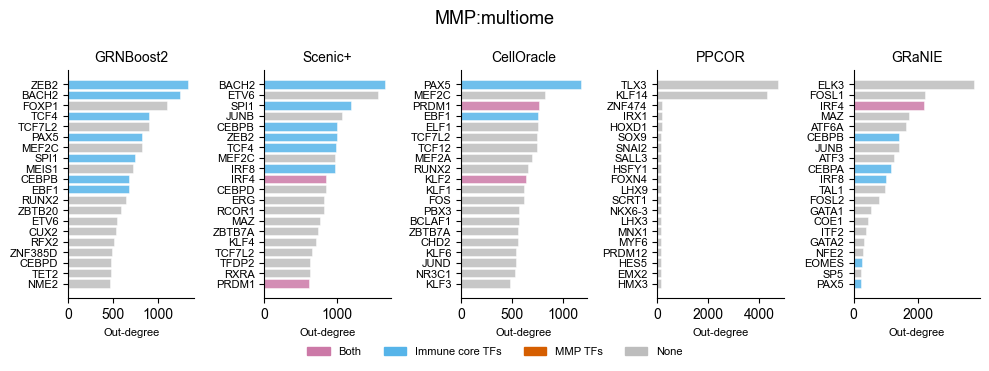

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig1_top20_tfs_mmp_multiome.png
── Dataset: MMP:dogma ──


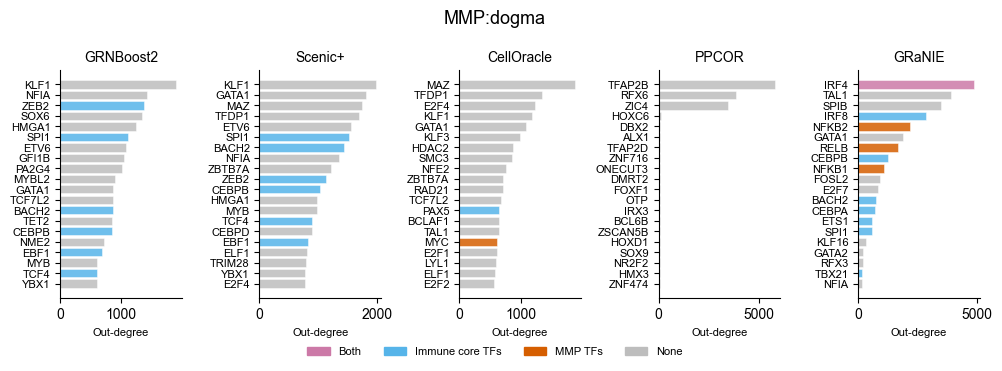

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig1_top20_tfs_mmp_dogma.png


In [34]:
for label, tag in DATASETS.items():
    print(f'── Dataset: MMP:{label} ──')
    fig_top_tfs(label, tag)

## 3. GWAS Analysis

In [35]:
print(f'MMP disease TFs (GWAS + literature): {len(MMP_TFS)}')
print(sorted(MMP_TFS))
print(f'\nImmune core TFs: {len(IMMUNE_CORE_TFS)}')
print(sorted(IMMUNE_CORE_TFS))


MMP disease TFs (GWAS + literature): 19
['HIF1A', 'IKZF1', 'IKZF3', 'IRF4', 'KLF2', 'MAF', 'MAFB', 'MAX', 'MYC', 'MYCN', 'NFKB1', 'NFKB2', 'PRDM1', 'RELA', 'RELB', 'SP140', 'SP3', 'STAT3', 'TP53']

Immune core TFs: 31
['BACH2', 'BATF', 'BCL11B', 'BCL6', 'CEBPA', 'CEBPB', 'EBF1', 'EOMES', 'ETS1', 'FOXP3', 'GATA3', 'IKZF1', 'IKZF2', 'IRF4', 'IRF7', 'IRF8', 'KLF2', 'LEF1', 'MAFB', 'PAX5', 'PRDM1', 'RORC', 'RUNX1', 'RUNX3', 'SPI1', 'TBX21', 'TCF4', 'TCF7', 'XBP1', 'ZEB2', 'ZNF683']


In [36]:
def fig_gwas_indegree(dataset_label, dataset_tag, gwas_genes):
    gwas_set = set(gwas_genes)
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f'MMP:{dataset_label}', fontsize=13, fontweight='bold')
    for ax, method in zip(axes, METHODS):
        grn = load_grn(dataset_tag, method)
        if grn is None:
            ax.set_title(surrogate_names[method]); ax.axis('off'); continue
        indeg = grn.groupby('target')['source'].count().sort_values(ascending=False).head(20)
        labels = indeg.index.tolist()
        values = indeg.values.tolist()
        colors = ['#E84040' if lbl in gwas_set else '#BDBDBD' for lbl in labels]
        y = range(len(labels))
        ax.barh(list(y), values, color=colors, edgecolor='white', linewidth=0.4, alpha=0.85)
        ax.set_yticks(list(y))
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_title(surrogate_names[method], fontsize=10)
        ax.set_xlabel('In-degree', fontsize=8)
    # legend
    from matplotlib.patches import Patch
    axes[-1].legend(handles=[Patch(color='#E84040', label='GWAS target'), Patch(color='#BDBDBD', label='Other')],
                    loc='lower right', fontsize=8, frameon=False)
    plt.tight_layout()
    out = os.path.join(OUT_DIR, f'fig_gwas_indegree_mmp_{dataset_label.lower()}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

── Dataset: MMP:multiome ──


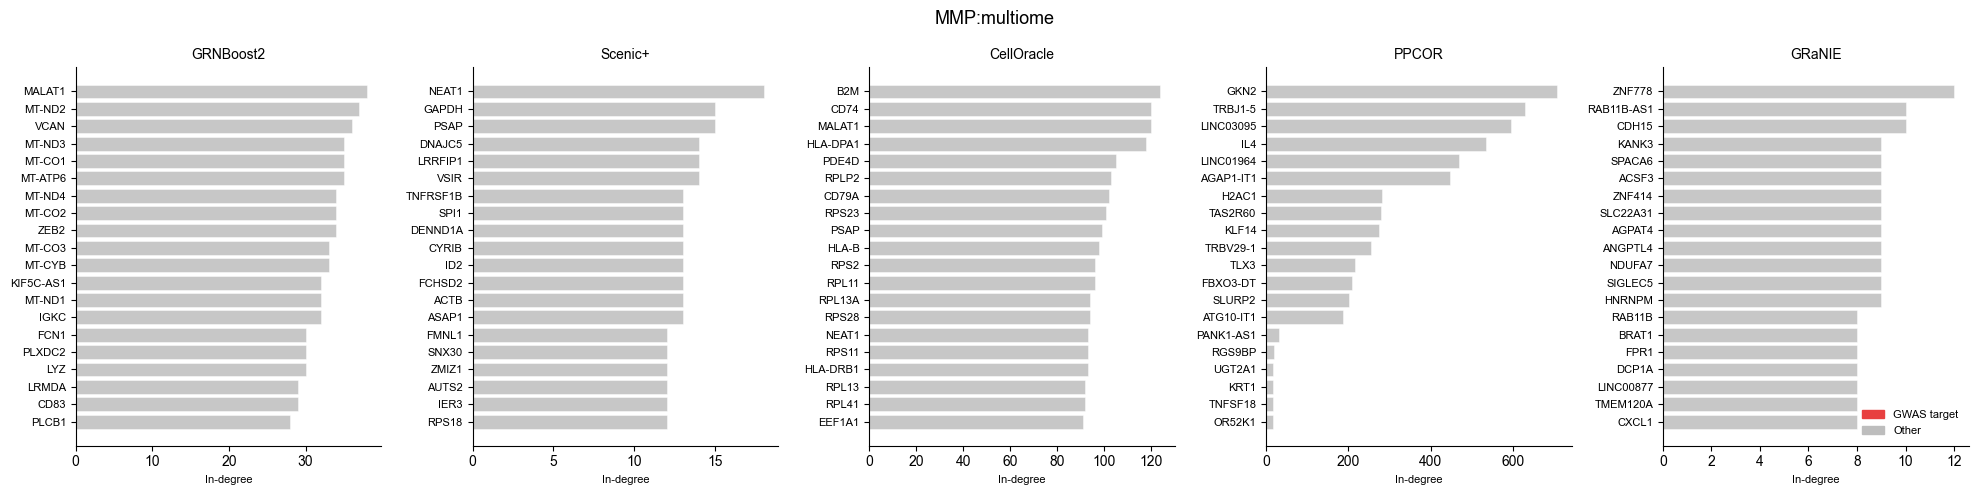

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_gwas_indegree_mmp_multiome.png
── Dataset: MMP:dogma ──


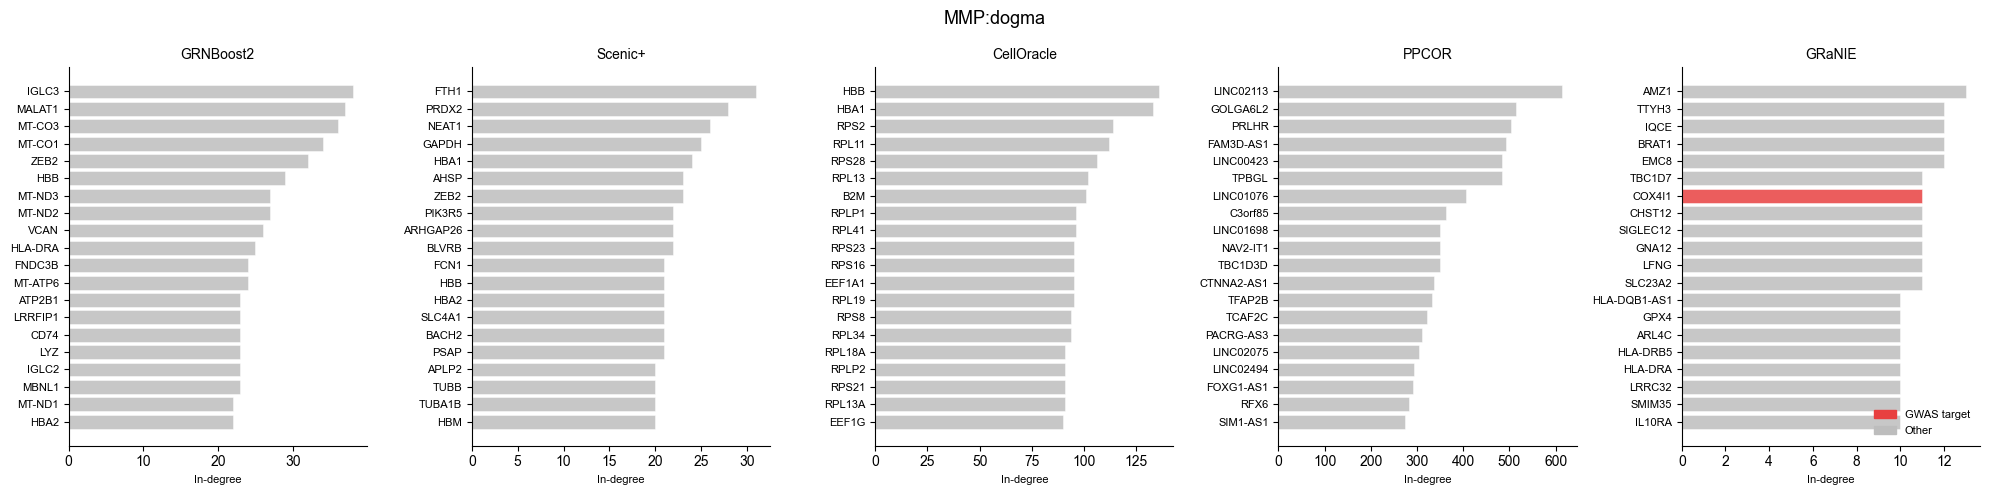

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_gwas_indegree_mmp_dogma.png


In [37]:
for label, tag in DATASETS.items():
    print(f'── Dataset: MMP:{label} ──')
    fig_gwas_indegree(label, tag, get_mmp_gwas_genes())

---
## GWAS Target Gene Enrichment

To assess whether GRN outputs capture disease-relevant regulatory architecture, we tested whether MMP GWAS-associated genes are preferentially targeted (higher in-degree) compared to background genes. We used 57 MMP GWAS genes mapped from genome-wide significant loci (p < 5×10⁻⁸) and performed a one-sided Mann–Whitney U test (GWAS > background) for each method × dataset combination.

**Results summary:**

| Method | Multiome | Dogma |
|--------|----------|-------|
| GRNBoost2 | ✅ significant | ** p=1.46e-3 |
| SCENIC+ | ** significant | ns (p≈0.05) |
| CellOracle | ns | * p=1.18e-2 |
| PPCOR | ns | ns |
| GRaNIE | ns | *** p=5.77e-5 |

**Interpretation:** GRNBoost2 and SCENIC+ show consistent enrichment in multiome, suggesting these methods capture biologically meaningful regulatory targeting of disease loci. GRaNIE shows strong enrichment in the dogma dataset. PPCOR — being correlation-based — does not discriminate GWAS vs background. Note: MMP GWAS gene sets are sparse (n=57) compared to complex inflammatory diseases such as IBD (n>1000), reflecting that MM pathogenesis is driven primarily by somatic translocations rather than germline variation.

## 3a. GWAS Target Gene Enrichment

Test whether MMP GWAS-associated genes are preferentially targeted (higher in-degree)
compared to background genes in each GRN. Uses all GWAS-mapped genes (not just TFs)
at genome-wide significance (p < 5×10⁻⁸). Statistical test: one-sided Mann-Whitney U
(H₁: GWAS genes have higher in-degree than non-GWAS genes).

MMP GWAS genes: 128


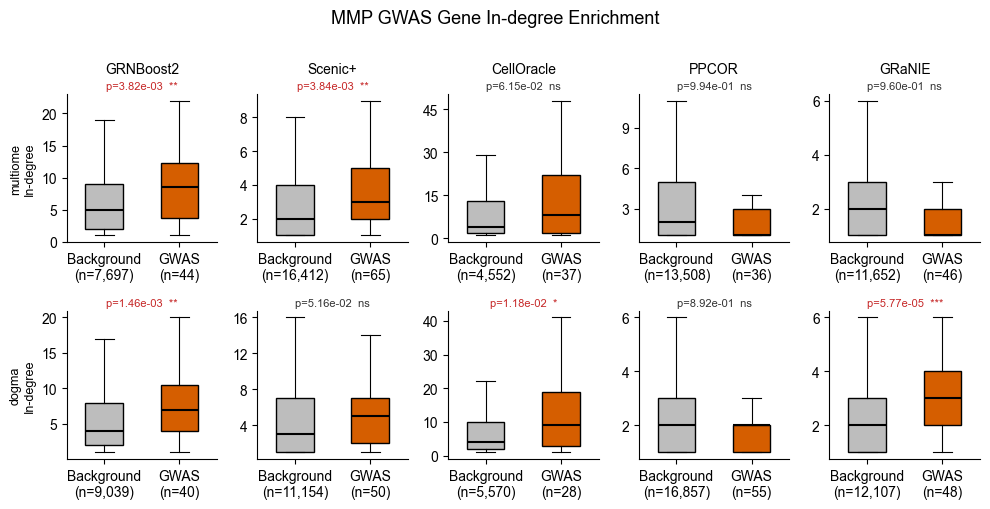

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_gwas_target_enrichment_mmp.png


In [49]:
def get_mmp_gwas_genes(pvalue_mlog_min=7.3):
    """All MMP GWAS-mapped genes at genome-wide significance (not just TFs)."""
    import pickle, pandas as pd
    gwas = pickle.load(open(GWAS_PATH, 'rb'))
    mask = gwas['DISEASE/TRAIT'].str.lower().str.contains(
        'multiple myeloma|plasma cell myeloma|myeloma|mgus|monoclonal gammopathy|smoldering',
        na=False)
    sub = gwas[mask][gwas[mask]['PVALUE_MLOG'] >= pvalue_mlog_min]
    genes = set()
    for col in ['REPORTED GENE(S)', 'MAPPED_GENE']:
        sub[col].dropna().apply(
            lambda s: genes.update(
                g.strip() for g in s.replace(' - ', ', ').split(',')
                if g.strip() and g.strip() != 'NR'
            ))
    return genes

def fig_gwas_target_enrichment():
    from scipy.stats import mannwhitneyu
    import matplotlib.ticker as mticker

    gwas_genes = get_mmp_gwas_genes()
    print(f'MMP GWAS genes: {len(gwas_genes)}')

    ds_labels = list(DATASETS.keys())     # ['multiome', 'dogma']
    ds_tags   = list(DATASETS.values())
    n_ds, n_m = len(ds_labels), len(METHODS)

    fig, axes = plt.subplots(n_ds, n_m, figsize=(n_m * 2, n_ds * 2.5), sharey=False)
    if n_ds == 1: axes = axes[None, :]

    for r, (ds_label, ds_tag) in enumerate(zip(ds_labels, ds_tags)):
        for c, method in enumerate(METHODS):
            ax = axes[r, c]
            grn = load_grn(ds_tag, method)
            if grn is None:
                ax.axis('off')
                ax.set_title(surrogate_names[method])
                continue

            indeg = grn.groupby('target')['source'].count()

            gwas_vals  = indeg[indeg.index.isin(gwas_genes)].values
            other_vals = indeg[~indeg.index.isin(gwas_genes)].values

            # Mann-Whitney U (one-sided: GWAS > background)
            if len(gwas_vals) >= 3:
                _, p = mannwhitneyu(gwas_vals, other_vals, alternative='greater')
            else:
                p = float('nan')

            # stars
            if   p < 0.001: stars = '***'
            elif p < 0.01:  stars = '**'
            elif p < 0.05:  stars = '*'
            else:           stars = 'ns'

            # boxplot
            bp = ax.boxplot(
                [other_vals, gwas_vals],
                labels=[f'Background\n(n={len(other_vals):,})', f'GWAS\n(n={len(gwas_vals)})'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5),
                showfliers=False,
                widths=0.5,
            )
            bp['boxes'][0].set_facecolor('#BDBDBD')
            bp['boxes'][1].set_facecolor('#D55E00')
            for elem in ['whiskers','caps']:
                for patch in bp[elem]: patch.set_linewidth(0.8)

            # p-value annotation (axes-relative coordinates)
            ax.text(0.5, 1.02, f'p={p:.2e}  {stars}',
                    transform=ax.transAxes, ha='center', va='bottom', fontsize=8,
                    color='#333333' if stars == 'ns' else '#c62828')

            if r == 0: ax.set_title(surrogate_names[method], fontsize=10, pad=15)
            if c == 0: ax.set_ylabel(f'{ds_label}\nIn-degree', fontsize=9)
            ax.spines[['top', 'right']].set_visible(False)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=5))

    fig.suptitle('MMP GWAS Gene In-degree Enrichment', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig_gwas_target_enrichment_mmp.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

fig_gwas_target_enrichment()


METHODS_c
For each GRN method, take the union of TF sources across multiome + dogma, then compare against the annotated TF set (PBMC markers ∪ MMP GWAS TFs). Report how many are missing per method.

In [39]:
immune_set = set(IMMUNE_CORE_TFS)
mmp_set   = MMP_TFS

method_tfs = {}
for m in METHODS:
    tfs = set()
    for tag in DATASETS.values():
        grn = load_grn(tag, m)
        if grn is not None:
            tfs |= set(grn['source'].unique())
    method_tfs[m] = tfs
    print(f'{surrogate_names[m]:12s}: {len(tfs):,} unique TFs (multiome ∪ dogma)')

universe = set().union(*method_tfs.values())
immune_universe = immune_set & universe
mmp_universe  = mmp_set  & universe
print(f'\nUniverse: {len(universe):,} TFs')
print(f'PBMC core TFs in universe: {len(immune_universe)}/{len(immune_set)}')
print(f'MMP GWAS TFs in universe:  {len(mmp_universe)}/{len(mmp_set)}')

# Which PBMC markers are missing from each method?
method_missing = {}
for m in METHODS:
    missing = (immune_set | mmp_set) - method_tfs[m]
    method_missing[m] = missing
    print(f'  {surrogate_names[m]:12s}: {len(missing)} missing annotated TFs')

GRNBoost2   : 1,412 unique TFs (multiome ∪ dogma)
Scenic+     : 471 unique TFs (multiome ∪ dogma)
CellOracle  : 591 unique TFs (multiome ∪ dogma)
PPCOR       : 1,466 unique TFs (multiome ∪ dogma)
GRaNIE      : 400 unique TFs (multiome ∪ dogma)

Universe: 1,695 TFs
PBMC core TFs in universe: 31/31
MMP GWAS TFs in universe:  19/19
  GRNBoost2   : 0 missing annotated TFs
  Scenic+     : 9 missing annotated TFs
  CellOracle  : 2 missing annotated TFs
  PPCOR       : 0 missing annotated TFs
  GRaNIE      : 21 missing annotated TFs


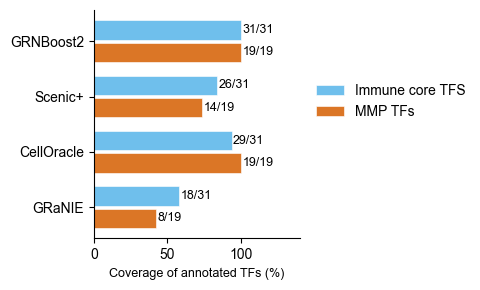

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_tf_coverage_mmp.png


In [40]:
def fig_tf_coverage():
    m_tfs = {}
    METHODS_c = [m for m in METHODS if m not in ['ppcor']]
    for m in METHODS_c:
        tfs = set()
        for tag in DATASETS.values():
            grn = load_grn(tag, m)
            if grn is not None:
                tfs |= set(grn['source'].unique())
        m_tfs[m] = tfs
    
    universe     = set().union(*m_tfs.values())
    immune_universe = set(IMMUNE_CORE_TFS) & universe
    mmp_universe  = MMP_TFS & universe

    n_methods = len(METHODS_c)
    bar_h = 0.35
    fig, ax = plt.subplots(figsize=(5, 3))

    for i, m in enumerate(METHODS_c):
        for j, (cat, color, universe_set) in enumerate([
            ('Immune core TFS', _TF_COLOR_IMMUNE, immune_universe),
            ('MMP TFs',    _TF_COLOR_MMP,  mmp_universe),
        ]):
            cov   = len(universe_set & m_tfs[m])
            total = len(universe_set)
            
            pct   = 100 * cov / total if total > 0 else 0
            y     = i + (j - 0.5) * bar_h * 1.15
            ax.barh(y, pct, height=bar_h, color=color, alpha=0.85,
                    edgecolor='white', linewidth=0.5, label=cat if i == 0 else '_')
            ax.text(pct + 1, y, f'{cov}/{total}', va='center', ha='left', fontsize=9)

    ax.set_yticks(range(n_methods))
    ax.set_yticklabels([surrogate_names[m] for m in METHODS_c])
    ax.set_xlabel('Coverage of annotated TFs (%)', fontsize=9)
    ax.set_xlim(0, 140)
    ax.spines[['top', 'right']].set_visible(False)
    ax.invert_yaxis()
    ax.legend(frameon=False, loc=[1.05, .5])
    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig_tf_coverage_mmp.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

fig_tf_coverage()

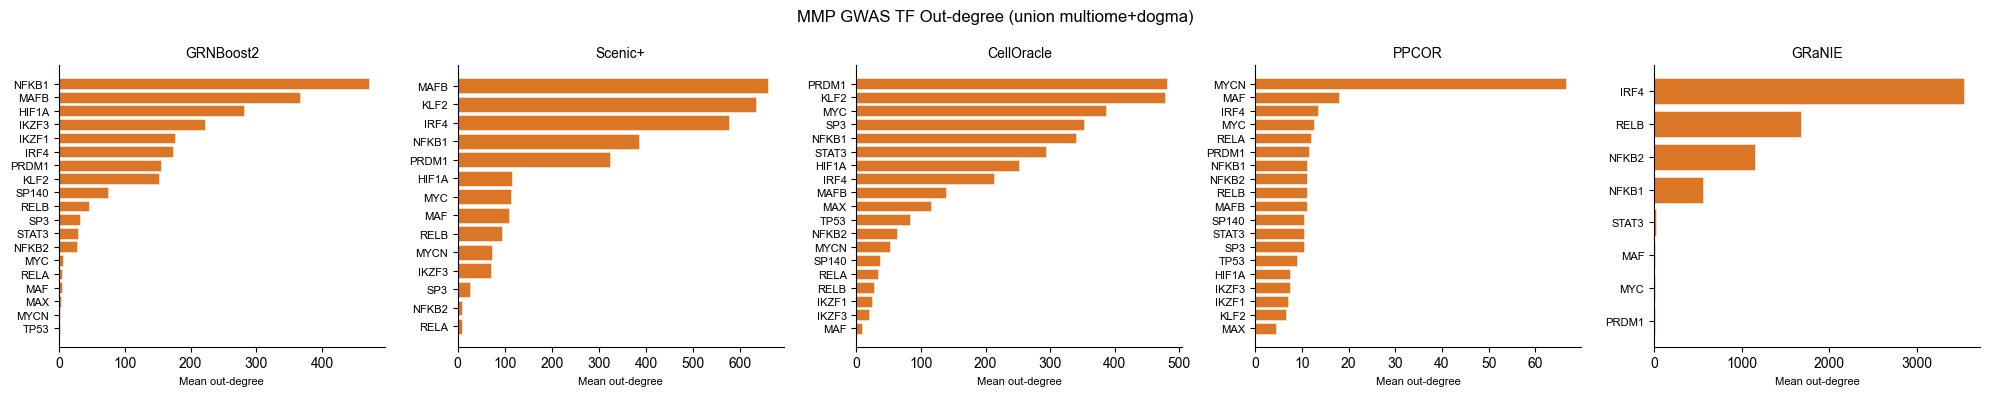

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_gwas_tf_summary_mmp.png


In [41]:
def fig_gwas_tf_summary():
    gwas_tfs = MMP_TFS
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle('MMP GWAS TF Out-degree (union multiome+dogma)', fontsize=12)
    for ax, m in zip(axes, METHODS):
        tfs, vals = [], []
        for tag in DATASETS.values():
            grn = load_grn(tag, m)
            if grn is None: continue
            od = grn.groupby('source')['target'].count()
            for tf in gwas_tfs:
                if tf in od.index:
                    tfs.append(tf); vals.append(od[tf])
        if not tfs:
            ax.set_title(surrogate_names[m]); ax.axis('off'); continue
        df = pd.DataFrame({'tf': tfs, 'od': vals}).groupby('tf')['od'].mean()
        df = df.sort_values(ascending=False).head(20)
        ax.barh(range(len(df)), df.values, color=_TF_COLOR_MMP, alpha=0.85,
                edgecolor='white', linewidth=0.4)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels(df.index.tolist(), fontsize=8)
        ax.invert_yaxis()
        ax.set_title(surrogate_names[m], fontsize=10)
        ax.set_xlabel('Mean out-degree', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig_gwas_tf_summary_mmp.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

fig_gwas_tf_summary()

## 3c. Motif Database Coverage of Missing Annotated TFs

For each method, we ask: among the annotated TFs (PBMC markers ∪ MMP GWAS TFs) missed by that method,
is the absence explained by the TF having no motif in the underlying database, or does the TF have a
motif but get filtered out by the method's downstream enrichment thresholds?

- **CellOracle** uses [JASPAR2022](https://jaspar.elixir.no/) motifs (`JASPAR2022-hg38.bed.gz`).
- **SCENIC+** uses the aeretslab cisTarget v10 motif database (`motifs-v10-nr.hgnc-m0.00001-o0.0.tbl`).
- **GRaNIE** uses [HOCOMOCO v12](https://hocomoco12.autosome.org/) in-vivo motifs (`PWMScan_HOCOMOCOv12_H12INVIVO`).

In [42]:
import gzip, os as _os

JASPAR_BED       = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/databases/scglue/JASPAR2022-hg38.bed.gz'
MOTIF_SCENIC_TBL = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/databases/scenicplus/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl'
HOCOMOCO_DIR     = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/databases/granie/H12INVIVO'

jaspar_tfs = set()
with gzip.open(JASPAR_BED, 'rt') as fh:
    for line in fh:
        parts = line.strip().split('\t')
        if len(parts) >= 4:
            jaspar_tfs.add(parts[3].upper())

sp_df = pd.read_csv(MOTIF_SCENIC_TBL, sep='\t', comment='#', header=None,
                    low_memory=False,
                    names=open(MOTIF_SCENIC_TBL).readline().strip().split('\t'))
sp_motif_tfs = set(sp_df['gene_name'].dropna().str.strip().str.upper())

hocomoco_tfs = set(f.split('.')[0].upper() for f in _os.listdir(HOCOMOCO_DIR))

print(f'CellOracle motif TFs (JASPAR2022)  : {len(jaspar_tfs):,}')
print(f'SCENIC+    motif TFs (cisTarget v10): {len(sp_motif_tfs):,}')
print(f'GRaNIE     motif TFs (HOCOMOCO v12) : {len(hocomoco_tfs):,}')

method_motif_db = {
    'celloracle': jaspar_tfs,
    'scenicplus' : sp_motif_tfs,
    'granie'     : hocomoco_tfs,
}

print()
for m, motif_db in method_motif_db.items():
    missing = method_missing.get(m, set())
    no_motif  = {tf for tf in missing if tf not in motif_db}
    has_motif = missing - no_motif
    print(f'── {surrogate_names[m]} ──────────────────')
    print(f'  Missing annotated TFs: {len(missing)}')
    print(f'  Absent from motif DB : {len(no_motif)} → {sorted(no_motif)}')
    print(f'  Have motif, filtered : {len(has_motif)} → {sorted(has_motif)}')
    print()

CellOracle motif TFs (JASPAR2022)  : 634
SCENIC+    motif TFs (cisTarget v10): 1,605
GRaNIE     motif TFs (HOCOMOCO v12) : 951

── CellOracle ──────────────────
  Missing annotated TFs: 2
  Absent from motif DB : 2 → ['FOXP3', 'ZEB2']
  Have motif, filtered : 0 → []

── Scenic+ ──────────────────
  Missing annotated TFs: 9
  Absent from motif DB : 0 → []
  Have motif, filtered : 9 → ['BATF', 'BCL11B', 'FOXP3', 'IKZF1', 'MAX', 'SP140', 'STAT3', 'TP53', 'ZNF683']

── GRaNIE ──────────────────
  Missing annotated TFs: 21
  Absent from motif DB : 11 → ['BCL11B', 'EBF1', 'IKZF1', 'IKZF2', 'IKZF3', 'RELA', 'RORC', 'SP140', 'TCF4', 'TP53', 'ZNF683']
  Have motif, filtered : 10 → ['BATF', 'GATA3', 'HIF1A', 'KLF2', 'MAFB', 'MAX', 'MYCN', 'SP3', 'TCF7', 'XBP1']



## 4. Centrality Shift: Multiome vs Dogma

For each method, compare TF out-degree between the two measurement modalities.

In [43]:
def fig_centrality_shift():
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    fig.suptitle('TF Out-degree Shift: Dogma − Multiome', fontsize=12, fontweight='bold')
    immune_set = set(IMMUNE_CORE_TFS)
    mmp_set   = MMP_TFS
    for ax, method in zip(axes, METHODS):
        grn_mo  = load_grn('multiome', method)
        grn_dog = load_grn('dogma', method)
        if grn_mo is None or grn_dog is None:
            ax.set_title(surrogate_names[method]); ax.axis('off'); continue
        od_mo  = grn_mo.groupby('source')['target'].count()
        od_dog = grn_dog.groupby('source')['target'].count()
        common = set(od_mo.index) & set(od_dog.index)
        delta  = pd.Series({tf: od_dog[tf] - od_mo[tf] for tf in common})
        top    = pd.concat([delta.nlargest(10), delta.nsmallest(10)]).sort_values()
        bar_colors = [_tf_color(tf, immune_set, mmp_set) for tf in top.index]
        ax.barh(range(len(top)), top.values, color=bar_colors, edgecolor='white',
                linewidth=0.4, alpha=0.85)
        ax.set_yticks(range(len(top)))
        ax.set_yticklabels(top.index.tolist(), fontsize=7)
        ax.axvline(0, color='grey', linewidth=0.8)
        ax.set_title(surrogate_names[method], fontsize=10)
        ax.set_xlabel('Δ out-degree (dogma − multiome)', fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    legend_handles = [
        mpatches.Patch(color=_TF_COLOR_BOTH, label='Both'),
        mpatches.Patch(color=_TF_COLOR_IMMUNE, label='Immune core TFs'),
        mpatches.Patch(color=_TF_COLOR_MMP,  label='MMP TFs'),
        mpatches.Patch(color=_TF_COLOR_NONE, label='None'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False,
               fontsize=8, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    out = os.path.join(OUT_DIR, 'fig_centrality_shift_mmp.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

── Centrality shift multiome vs dogma ──


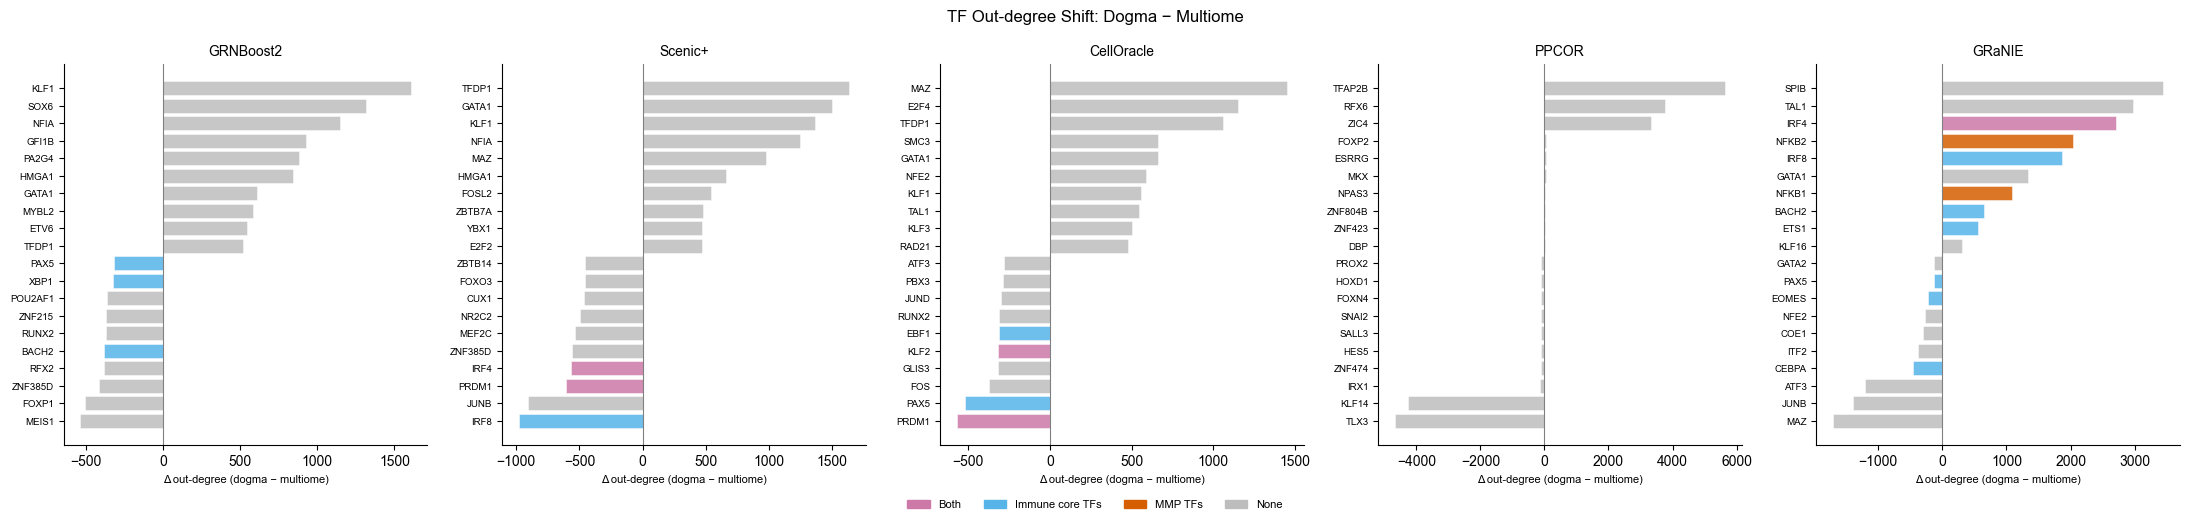

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_centrality_shift_mmp.png
Done.


In [44]:
print('── Centrality shift multiome vs dogma ──')
fig_centrality_shift()
print('Done.')

## 5. Multiome vs Dogma Differential Network Analysis

Compares GRN edges between the two measurement modalities for a selected model.
Identifies modality-specific edges and TFs with the largest connectivity differences.

In [45]:
# ── Parameters — change MODEL to any of the 5 methods ────────────────────────
MODEL = 'grnboost'
TOP_N = 20

In [46]:
grn_mo  = load_grn('multiome', MODEL).copy()
grn_dog = load_grn('dogma',    MODEL).copy()
grn_mo['weight']  = grn_mo['weight'].astype(float)
grn_dog['weight'] = grn_dog['weight'].astype(float)

edges_mo  = set(zip(grn_mo['source'],  grn_mo['target']))
edges_dog = set(zip(grn_dog['source'], grn_dog['target']))
dog_only   = edges_dog - edges_mo
mo_only    = edges_mo  - edges_dog
shared     = edges_mo  & edges_dog

df_dog_only = grn_dog[grn_dog.apply(lambda r: (r['source'], r['target']) in dog_only, axis=1)]
df_mo_only  = grn_mo[grn_mo.apply(lambda r:   (r['source'], r['target']) in mo_only,  axis=1)]

print(f'Multiome-only edges : {len(mo_only):,}')
print(f'Shared edges        : {len(shared):,}')
print(f'Dogma-only edges    : {len(dog_only):,}')

Multiome-only edges : 31,653
Shared edges        : 18,347
Dogma-only edges    : 31,653


In [47]:
tf_dog = df_dog_only.groupby('source')['target'].count().rename('dogma_only')
tf_mo  = df_mo_only.groupby('source')['target'].count().rename('multiome_only')
tgt_dog = df_dog_only.groupby('target')['source'].count().rename('dogma_only')
tgt_mo  = df_mo_only.groupby('target')['source'].count().rename('multiome_only')

df_tfs  = pd.concat([tf_mo, tf_dog], axis=1).fillna(0).astype(int)
df_tgts = pd.concat([tgt_mo, tgt_dog], axis=1).fillna(0).astype(int)
df_tfs['delta']  = df_tfs['dogma_only']  - df_tfs['multiome_only']
df_tgts['delta'] = df_tgts['dogma_only'] - df_tgts['multiome_only']
print(df_tfs.reindex(df_tfs['delta'].abs().sort_values(ascending=False).index).head(10))

        multiome_only  dogma_only  delta
source                                  
KLF1               32        1638   1606
SOX6                0        1316   1316
NFIA               54        1198   1144
GFI1B              23         947    924
PA2G4              14         895    881
HMGA1              54         898    844
GATA1              54         660    606
MYBL2              47         630    583
ETV6              189         730    541
MEIS1             553          17   -536


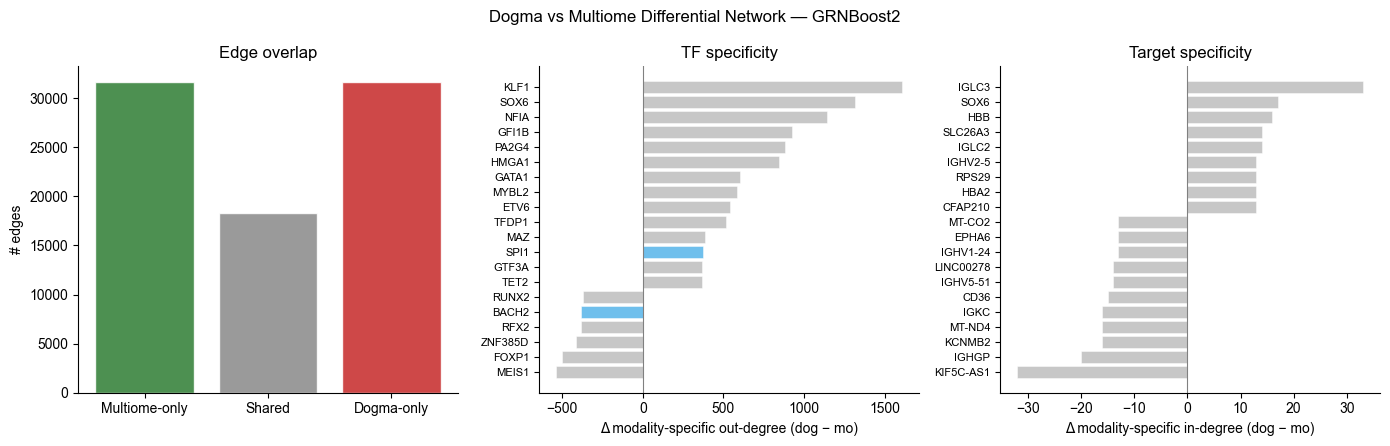

Saved: /home/jnourisa/projs/ongoing/task_grn_inference/resources/results/experiment/MMP/fig_diff_network_mmp_grnboost.png


In [48]:
immune_set = set(IMMUNE_CORE_TFS)
mmp_set   = MMP_TFS

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(f'Dogma vs Multiome Differential Network — {surrogate_names[MODEL]}',
             fontsize=12, fontweight='bold')

# Panel A: edge set breakdown
ax = axes[0]
counts = [len(mo_only), len(shared), len(dog_only)]
labels = ['Multiome-only', 'Shared', 'Dogma-only']
bar_colors = ['#2e7d32', '#888888', '#c62828']
ax.bar(labels, counts, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('# edges')
ax.set_title('Edge overlap')
ax.spines[['top', 'right']].set_visible(False)

# Panel B: top TFs by modality-specific out-degree
ax = axes[1]
top_tfs = df_tfs['delta'].abs().sort_values(ascending=False).head(TOP_N)
top_df  = df_tfs.loc[top_tfs.index].sort_values('delta')
colors_ = [_tf_color(tf, immune_set, mmp_set) for tf in top_df.index]
ax.barh(range(len(top_df)), top_df['delta'], color=colors_, alpha=0.85,
        edgecolor='white', linewidth=0.4)
ax.set_yticks(range(len(top_df)))
ax.set_yticklabels(top_df.index.tolist(), fontsize=8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Δ modality-specific out-degree (dog − mo)')
ax.set_title('TF specificity')
ax.spines[['top', 'right']].set_visible(False)

# Panel C: top target genes
ax = axes[2]
top_tgts = df_tgts['delta'].abs().sort_values(ascending=False).head(TOP_N)
top_tg   = df_tgts.loc[top_tgts.index].sort_values('delta')
colors_t = [_tf_color(tf, immune_set, mmp_set) for tf in top_tg.index]
ax.barh(range(len(top_tg)), top_tg['delta'], color=colors_t, alpha=0.85,
        edgecolor='white', linewidth=0.4)
ax.set_yticks(range(len(top_tg)))
ax.set_yticklabels(top_tg.index.tolist(), fontsize=8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Δ modality-specific in-degree (dog − mo)')
ax.set_title('Target specificity')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = os.path.join(OUT_DIR, f'fig_diff_network_mmp_{MODEL}.png')
plt.savefig(out, dpi=150, bbox_inches='tight', transparent=True)
plt.show()
print(f'Saved: {out}')